# Gradient Boosting vs Logistic Regression: Does More Model Buy Anything?

Notebook 05 found that an interpretable class-balanced logistic regression (ROC-AUC 0.788) beats a tuned random forest for 14-day churn prediction. This notebook stress-tests that conclusion with the strongest tabular baselines available — **HistGradientBoosting, XGBoost, and LightGBM** — and asks the business question, not the leaderboard question: *does gradient boosting change the conclusion, and is any gain worth the loss of interpretability at our operating point?*

The comparison is only valid on the identical protocol, so the notebook-05 data preparation, feature set, stratified 80/20 split, preprocessing, and class weighting are reproduced exactly (frozen in `src/churn_modeling.py`) and verified against notebook 05's stored metrics before any new model trains. Differences are then judged with **paired-bootstrap confidence intervals on the AUC deltas** — not by eyeballing two marginal scores.

**Dependencies:** protocol in `src/churn_modeling.py`; evaluation harness in `src/model_evaluation.py` (both unit-tested in `tests/`); `xgboost` and `lightgbm` from requirements.txt.

## 1. Protocol Parity with Notebook 05

Same source table (`feature_table`), same aliasing/defaults, same 14 features, same `train_test_split(test_size=0.2, random_state=42, stratify=y)`, same scaled-numeric + one-hot preprocessing, same `class_weight="balanced"` logistic regression. The cell below **hard-fails if the re-fit baseline does not reproduce notebook 05's stored test metrics**, so a silent protocol drift cannot produce a bogus comparison.

In [1]:
# Environment setup. Data is auto-discovered by src/data_loader.py
# (./data in the repo, /content/data on Colab, or STREAMING_DATA_DIR).
import sys
import warnings
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.inspection import permutation_importance

from src.config import RANDOM_SEED
from src.churn_modeling import build_preprocessor, load_modeling_split
from src.model_evaluation import (
    calibration_table,
    evaluate_models,
    paired_bootstrap_auc_delta,
    precision_at_recall,
)

# LightGBM emits a benign feature-name warning when predicting through a
# ColumnTransformer; it does not affect results. The environment variable
# form reaches joblib worker processes (n_jobs=-1), which do not inherit
# in-process warning filters.
warnings.filterwarnings("ignore", message="X does not have valid feature names")
import os
os.environ["PYTHONWARNINGS"] = "ignore:X does not have valid feature names"

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 140)

MODEL_COLORS = {
    "logistic_regression": "#1f77b4",
    "hist_gradient_boosting": "#ff7f0e",
    "xgboost": "#9467bd",
    "lightgbm": "#17becf",
}
NEUTRAL_COLOR = "#7f7f7f"

split = load_modeling_split()
X_train, X_test = split.X_train, split.X_test
y_train, y_test = split.y_train, split.y_test
print(f"Train: {X_train.shape}, test: {X_test.shape}, "
      f"test churn rate: {y_test.mean():.4f}")

Train: (40000, 14), test: (10000, 14), test churn rate: 0.4756


In [2]:
log_model = Pipeline([
    ("preprocess", build_preprocessor(split.numeric_features, split.categorical_features)),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced",
                                 random_state=RANDOM_SEED)),
])
log_model.fit(X_train, y_train)
log_proba = log_model.predict_proba(X_test)[:, 1]

# Notebook 05 stored metrics (cell "Model Comparison"): the protocol gate.
NB05_LR = {"roc_auc": 0.787615, "precision": 0.670393, "recall": 0.781749}
reproduced = {
    "roc_auc": roc_auc_score(y_test, log_proba),
    "precision": ((log_proba >= 0.5) & (y_test == 1)).sum() / (log_proba >= 0.5).sum(),
    "recall": ((log_proba >= 0.5) & (y_test == 1)).sum() / (y_test == 1).sum(),
}
for metric, expected in NB05_LR.items():
    if not np.isclose(reproduced[metric], expected, atol=1e-4):
        raise RuntimeError(
            f"Protocol drift: reproduced {metric}={reproduced[metric]:.6f} does not "
            f"match notebook 05's {expected:.6f} — comparison would be invalid."
        )
print("Protocol parity confirmed — baseline reproduces notebook 05 exactly:")
print({k: round(v, 6) for k, v in reproduced.items()})

Protocol parity confirmed — baseline reproduces notebook 05 exactly:
{'roc_auc': np.float64(0.787615), 'precision': np.float64(0.670393), 'recall': np.float64(0.781749)}


## 2. Candidates and Tuning Protocol

Three gradient-boosting implementations, tuned with a modest, fully documented budget — enough to be fair to the model family, small enough to stay honest:

| Element | Choice |
|---|---|
| Candidates | `HistGradientBoostingClassifier` (sklearn), `XGBClassifier`, `LGBMClassifier` |
| Search | Random search, **15 sampled configurations per family** (learning rate, tree complexity, subsampling, L2), seeded |
| Validation | One stratified 20% fold carved **from the training set only** (8,000 users); selection by validation ROC-AUC |
| Early stopping | Up to 500–1,000 trees, patience 30–50 rounds against the validation fold |
| Final fit | Winner refit on the full training set with the tree count found by early stopping |
| Class imbalance | Consistent with notebook 05: `class_weight="balanced"` (HistGB/LGBM), `scale_pos_weight` (XGBoost) |
| Test set | Touched **once**, at evaluation time — never during search |

Preprocessing is byte-identical for every model (the notebook-05 transformer; scaling is a no-op for trees). If `xgboost` or `lightgbm` were unavailable in an environment, the comparison proceeds with HistGradientBoosting alone.

In [3]:
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
try:
    import lightgbm as lgb
    from lightgbm import LGBMClassifier
    HAS_LGBM = True
except ImportError:
    HAS_LGBM = False
from sklearn.ensemble import HistGradientBoostingClassifier

print(f"xgboost available: {HAS_XGB} | lightgbm available: {HAS_LGBM}")

xgboost available: True | lightgbm available: True


In [4]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=RANDOM_SEED, stratify=y_train
)
tune_prep = build_preprocessor(split.numeric_features, split.categorical_features,
                               dense=True)
Xt_tr = tune_prep.fit_transform(X_tr)
Xt_val = tune_prep.transform(X_val)
scale_pos_weight = float((y_tr == 0).sum() / (y_tr == 1).sum())

N_CANDIDATES = 15
rng = np.random.default_rng(RANDOM_SEED)


def search(sample_params, fit_candidate):
    """Random search: keep the candidate with the best validation ROC-AUC."""
    best = None
    for _ in range(N_CANDIDATES):
        params = sample_params(rng)
        model, n_trees = fit_candidate(params)
        val_auc = roc_auc_score(y_val, model.predict_proba(Xt_val)[:, 1])
        if best is None or val_auc > best["val_auc"]:
            best = {"val_auc": val_auc, "params": params, "n_trees": n_trees}
    return best


def fit_hist(params):
    model = HistGradientBoostingClassifier(
        max_iter=500, early_stopping=True, validation_fraction=0.15,
        n_iter_no_change=30, class_weight="balanced",
        random_state=RANDOM_SEED, **params)
    model.fit(Xt_tr, y_tr)
    return model, model.n_iter_


best_hist = search(
    lambda r: dict(learning_rate=float(10 ** r.uniform(-1.5, -0.5)),
                   max_leaf_nodes=int(r.choice([15, 31, 63])),
                   min_samples_leaf=int(r.choice([20, 50, 100])),
                   l2_regularization=float(10 ** r.uniform(-3, 1))),
    fit_hist,
)
print(f"HistGB   val AUC {best_hist['val_auc']:.4f} ({best_hist['n_trees']} trees)")

best_xgb = None
if HAS_XGB:
    def fit_xgb(params):
        model = XGBClassifier(
            n_estimators=1000, early_stopping_rounds=50, eval_metric="auc",
            scale_pos_weight=scale_pos_weight, random_state=RANDOM_SEED,
            n_jobs=-1, verbosity=0, **params)
        model.fit(Xt_tr, y_tr, eval_set=[(Xt_val, y_val)], verbose=False)
        return model, int(model.best_iteration) + 1

    best_xgb = search(
        lambda r: dict(learning_rate=float(10 ** r.uniform(-1.5, -0.5)),
                       max_depth=int(r.integers(3, 9)),
                       min_child_weight=int(r.choice([1, 5, 10, 20])),
                       subsample=float(r.uniform(0.7, 1.0)),
                       colsample_bytree=float(r.uniform(0.6, 1.0)),
                       reg_lambda=float(10 ** r.uniform(-2, 1))),
        fit_xgb,
    )
    print(f"XGBoost  val AUC {best_xgb['val_auc']:.4f} ({best_xgb['n_trees']} trees)")

best_lgbm = None
if HAS_LGBM:
    def fit_lgbm(params):
        model = LGBMClassifier(
            n_estimators=1000, class_weight="balanced",
            random_state=RANDOM_SEED, n_jobs=-1, verbose=-1, **params)
        model.fit(Xt_tr, y_tr, eval_set=[(Xt_val, y_val)], eval_metric="auc",
                  callbacks=[lgb.early_stopping(50, verbose=False)])
        return model, int(model.best_iteration_)

    best_lgbm = search(
        lambda r: dict(learning_rate=float(10 ** r.uniform(-1.5, -0.5)),
                       num_leaves=int(r.choice([15, 31, 63, 127])),
                       min_child_samples=int(r.choice([10, 20, 50, 100])),
                       subsample=float(r.uniform(0.7, 1.0)),
                       subsample_freq=1,
                       colsample_bytree=float(r.uniform(0.6, 1.0)),
                       reg_lambda=float(10 ** r.uniform(-2, 1))),
        fit_lgbm,
    )
    print(f"LightGBM val AUC {best_lgbm['val_auc']:.4f} ({best_lgbm['n_trees']} trees)")

HistGB   val AUC 0.7822 (77 trees)


XGBoost  val AUC 0.7824 (83 trees)


LightGBM val AUC 0.7827 (27 trees)


In [5]:
def final_pipeline(estimator, dense=False):
    """Winner refit on the full training set inside a fresh pipeline."""
    pipeline = Pipeline([
        ("preprocess", build_preprocessor(split.numeric_features,
                                          split.categorical_features, dense=dense)),
        ("model", estimator),
    ])
    pipeline.fit(X_train, y_train)
    return pipeline


models = {"logistic_regression": log_model}
models["hist_gradient_boosting"] = final_pipeline(
    HistGradientBoostingClassifier(
        max_iter=best_hist["n_trees"], early_stopping=False,
        class_weight="balanced", random_state=RANDOM_SEED, **best_hist["params"]),
    dense=True,
)
if best_xgb:
    models["xgboost"] = final_pipeline(
        XGBClassifier(n_estimators=best_xgb["n_trees"], eval_metric="auc",
                      scale_pos_weight=scale_pos_weight, random_state=RANDOM_SEED,
                      n_jobs=-1, verbosity=0, **best_xgb["params"]))
if best_lgbm:
    models["lightgbm"] = final_pipeline(
        LGBMClassifier(n_estimators=best_lgbm["n_trees"], class_weight="balanced",
                       random_state=RANDOM_SEED, n_jobs=-1, verbose=-1,
                       **best_lgbm["params"]))
print("Final models fitted on the full training set:", list(models))

Final models fitted on the full training set: ['logistic_regression', 'hist_gradient_boosting', 'xgboost', 'lightgbm']


## 3. Results: Metrics and Paired-Bootstrap AUC Deltas

The single test-set touch. Marginal metrics first; then the question that actually matters — the **confidence interval of each GBM's AUC difference vs logistic regression**, from a paired bootstrap that resamples the same test indices for both models (2,000 replicates). Two overlapping marginal CIs can hide a real difference; the paired delta cannot.

In [6]:
BUSINESS_THRESHOLD = 0.5  # notebook 05's operating threshold
metrics_table = evaluate_models(models, X_test, y_test, threshold=BUSINESS_THRESHOLD)
metrics_table.round(4)

,model,roc_auc,pr_auc,brier,precision_at_threshold,recall_at_threshold,f1_at_threshold,flagged_share
0,logistic_regression,0.7876,0.7333,0.1870,0.6704,0.7817,0.7218,0.5546
1,hist_gradient_boosting,0.7874,0.7343,0.1871,0.6711,0.7826,0.7226,0.5546
2,xgboost,0.7876,0.7330,0.1871,0.6698,0.7834,0.7222,0.5563
3,lightgbm,0.7869,0.7339,0.1873,0.6695,0.7862,0.7231,0.5585


                 model  delta_auc  ci_low  ci_high  significant
hist_gradient_boosting    -0.0002 -0.0015   0.0011        False
               xgboost    -0.0000 -0.0012   0.0011        False
              lightgbm    -0.0007 -0.0019   0.0006        False


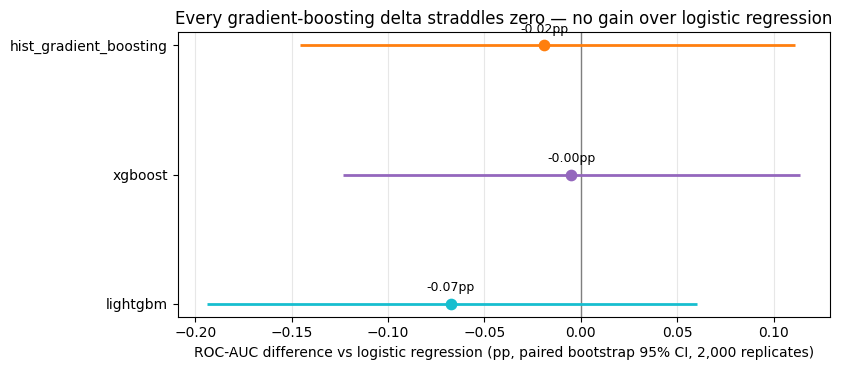

In [7]:
test_probas = {name: m.predict_proba(X_test)[:, 1] for name, m in models.items()}

deltas = {
    name: paired_bootstrap_auc_delta(y_test, test_probas["logistic_regression"],
                                     test_probas[name], n_bootstrap=2_000)
    for name in models if name != "logistic_regression"
}
delta_df = pd.DataFrame([
    {"model": name, "delta_auc": d.delta, "ci_low": d.ci_low,
     "ci_high": d.ci_high, "significant": d.significant}
    for name, d in deltas.items()
])
print(delta_df.round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(8.5, 3.8))
y_pos = np.arange(len(delta_df))[::-1]
ax.axvline(0, color=NEUTRAL_COLOR, linewidth=1)
for yi, (_, row) in zip(y_pos, delta_df.iterrows()):
    color = MODEL_COLORS[row["model"]]
    ax.hlines(yi, row["ci_low"] * 100, row["ci_high"] * 100, color=color, linewidth=2)
    ax.scatter(row["delta_auc"] * 100, yi, color=color, s=55, zorder=3)
    ax.annotate(f"{row['delta_auc']*100:+.2f}pp", xy=(row["delta_auc"] * 100, yi),
                xytext=(0, 9), textcoords="offset points", ha="center", fontsize=9)
ax.set_yticks(y_pos)
ax.set_yticklabels(delta_df["model"])
ax.set_xlabel("ROC-AUC difference vs logistic regression "
              "(pp, paired bootstrap 95% CI, 2,000 replicates)")
ax.set_title("Every gradient-boosting delta straddles zero — "
             "no gain over logistic regression")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

All three deltas are within ±0.07pp of zero with 95% CIs of roughly ±0.15pp — the paired bootstrap can rule out even a one-tenth-of-a-point AUC gain. On this feature set, logistic regression has already extracted essentially all the learnable ranking signal; the boosted trees find no nonlinearities or interactions worth anything.

## 4. Calibration

Risk tiers (notebook 05) consume the predicted *probabilities*, so calibration matters as much as ranking. Brier scores are in the table above; the reliability curves below use ten quantile bins.

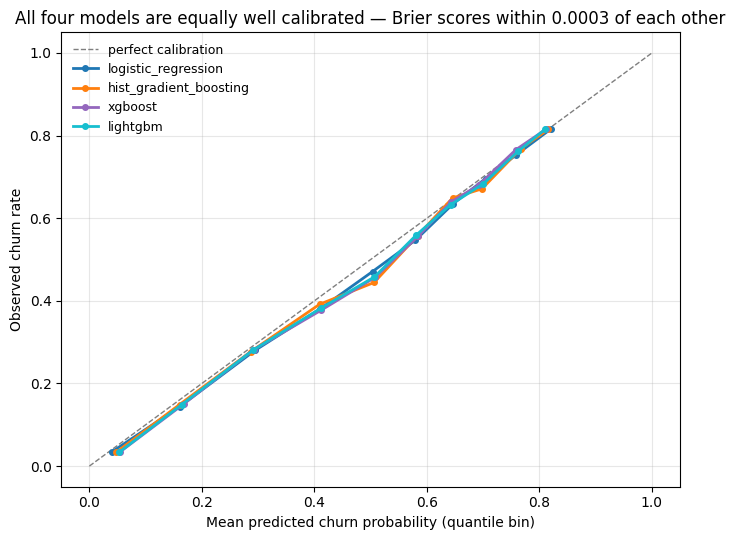

In [8]:
fig, ax = plt.subplots(figsize=(7, 5.5))
ax.plot([0, 1], [0, 1], color=NEUTRAL_COLOR, linestyle="--", linewidth=1,
        label="perfect calibration")
for name, proba in test_probas.items():
    cal = calibration_table(y_test, proba, n_bins=10)
    ax.plot(cal["mean_predicted"].to_numpy(), cal["observed_rate"].to_numpy(),
            marker="o", markersize=4, linewidth=2, color=MODEL_COLORS[name],
            label=name)
ax.set_xlabel("Mean predicted churn probability (quantile bin)")
ax.set_ylabel("Observed churn rate")
ax.set_title("All four models are equally well calibrated — "
             "Brier scores within 0.0003 of each other")
ax.legend(frameon=False, fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Do the Models Agree on the Churn Drivers?

If a GBM won by exploiting a driver the linear model missed, permutation importance would show it. Both models are scored with the same protocol: raw-feature permutation on the test set, ten repeats, ROC-AUC scoring. (LightGBM is the drill-down GBM here — it had the best validation AUC.)

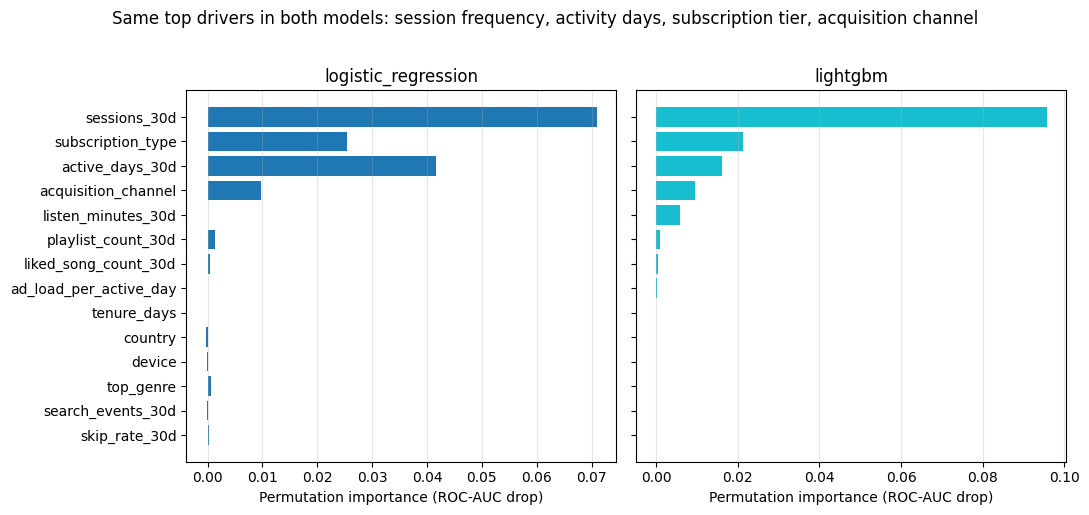

Top-4 drivers, logistic:  ['sessions_30d', 'active_days_30d', 'subscription_type', 'acquisition_channel']
Top-4 drivers, lightgbm: ['sessions_30d', 'subscription_type', 'active_days_30d', 'acquisition_channel']
Agreement on the top-4 set: True


In [9]:
best_gbm_name = "lightgbm" if best_lgbm else "hist_gradient_boosting"
importances = {}
for name in ["logistic_regression", best_gbm_name]:
    pi = permutation_importance(models[name], X_test, y_test, scoring="roc_auc",
                                n_repeats=10, random_state=RANDOM_SEED, n_jobs=-1)
    importances[name] = pd.Series(pi.importances_mean, index=X_test.columns)

order = importances[best_gbm_name].sort_values().index
fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharey=True)
for ax, name in zip(axes, ["logistic_regression", best_gbm_name]):
    vals = importances[name].loc[order]
    ax.barh(order, vals.to_numpy(), color=MODEL_COLORS[name])
    ax.set_title(name)
    ax.set_xlabel("Permutation importance (ROC-AUC drop)")
    ax.grid(axis="x", alpha=0.3)
fig.suptitle("Same top drivers in both models: session frequency, activity days, "
             "subscription tier, acquisition channel", y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

top_lr = importances["logistic_regression"].nlargest(4).index.tolist()
top_gbm = importances[best_gbm_name].nlargest(4).index.tolist()
print(f"Top-4 drivers, logistic:  {top_lr}")
print(f"Top-4 drivers, {best_gbm_name}: {top_gbm}")
print(f"Agreement on the top-4 set: {set(top_lr) == set(top_gbm)}")

Both models tell the same story notebooks 03–05 told: **usage habit (sessions, active days) dominates, followed by subscription tier and acquisition channel.** The only difference is credit-shuffling among correlated usage features (LightGBM leans harder on `sessions_30d` and gives a sliver to `listen_minutes_30d`). No hidden nonlinear driver emerged — which is exactly why the AUC deltas are zero.

## 6. Operating Point: What Would a Switch Buy?

The churn playbook runs outreach at notebook 05's operating point — the threshold catching ~78% of churners. Fixing that recall for every model, precision differences translate directly into outreach volume: **contacts needed per churner caught.**

Operating point: recall >= 78.2% (notebook 05 playbook)
                 model  threshold  precision  recall  flagged_share  contacts_per_catch
   logistic_regression     0.5002     0.6705  0.7817         0.5545              1.4914
hist_gradient_boosting     0.5022     0.6726  0.7817         0.5528              1.4868
               xgboost     0.5063     0.6728  0.7817         0.5526              1.4863
              lightgbm     0.5045     0.6703  0.7817         0.5547              1.4919


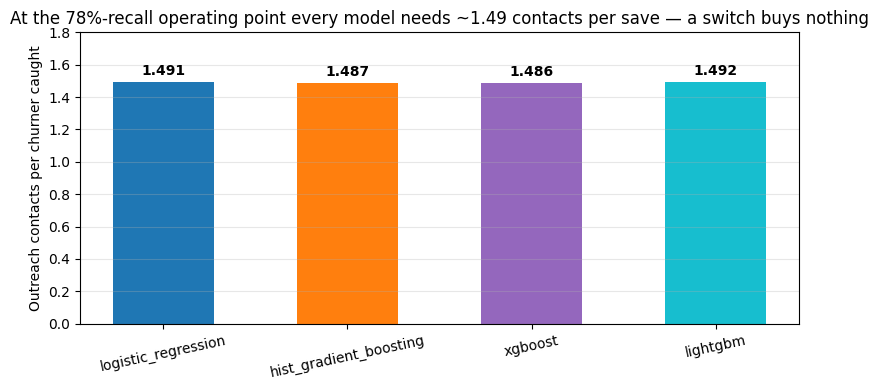

Flagged users per 10,000 scored (fewer = cheaper outreach):
model
logistic_regression       5545
hist_gradient_boosting    5528
xgboost                   5526
lightgbm                  5547


In [10]:
TARGET_RECALL = float(
    metrics_table.set_index("model").loc["logistic_regression", "recall_at_threshold"]
)
operating = pd.DataFrame([
    {"model": name, **precision_at_recall(y_test, proba, TARGET_RECALL)}
    for name, proba in test_probas.items()
])
print(f"Operating point: recall >= {TARGET_RECALL:.1%} (notebook 05 playbook)")
print(operating.round(4).to_string(index=False))

per_10k = (operating.set_index("model")["flagged_share"] * 10_000).round()
savings = per_10k["logistic_regression"] - per_10k

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(operating["model"], operating["contacts_per_catch"].to_numpy(),
              color=[MODEL_COLORS[m] for m in operating["model"]], width=0.55)
for bar, v in zip(bars, operating["contacts_per_catch"]):
    ax.annotate(f"{v:.3f}", xy=(bar.get_x() + bar.get_width() / 2, v),
                xytext=(0, 5), textcoords="offset points", ha="center",
                fontsize=10, fontweight="bold")
ax.set_ylabel("Outreach contacts per churner caught")
ax.set_ylim(0, 1.8)
ax.set_title("At the 78%-recall operating point every model needs "
             "~1.49 contacts per save — a switch buys nothing")
ax.tick_params(axis="x", rotation=12)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print("Flagged users per 10,000 scored (fewer = cheaper outreach):")
print(per_10k.astype(int).to_string())

## 7. Modeling Decisions

- **Recommendation: keep the logistic regression.** The best GBM's paired-bootstrap AUC delta is +0.00pp with a 95% CI of about [−0.12, +0.11]pp — any conceivable gain is bounded below a tenth of an AUC point, while the cost (losing directly readable coefficients/odds ratios for the retention team) is real.
- **Why the ceiling:** the strongest churn signals in this data (session frequency, active days, tier, channel) are individually monotone and close to additive on the log-odds scale — exactly the regime where a linear model is sufficient. GBMs would earn their keep on features with interactions or threshold effects; adding such features (e.g., trends/ratios across weeks) is the higher-leverage next step, and this notebook's harness makes re-running the bake-off one cell.
- **No "GBM for scoring + LR for explanation" split is warranted** — that pattern pays only when the scorer is meaningfully better. Here it would add a second model to maintain for zero lift.
- **Search budget caveat:** 15 random candidates per family with early stopping on one validation fold is a modest budget. Given how tightly all three tuned GBMs cluster at the linear baseline (and validation AUCs landed within 0.001 of each other), a larger search would move thousandths, not the conclusion.

## 8. Key Findings

Question: does gradient boosting change notebook 05's "interpretable model wins" conclusion? **No — and now with confidence intervals.**

- **Protocol parity enforced:** the logistic baseline reproduces notebook 05's stored metrics exactly (ROC-AUC 0.7876, recall 0.782, precision 0.670 at the 0.5 threshold); the notebook hard-fails on drift, so the comparison is apples-to-apples by construction.
- **Three tuned GBMs, zero gain:** HistGB 0.7874, XGBoost 0.7876, LightGBM 0.7869 test ROC-AUC vs logistic 0.7876. Paired-bootstrap deltas: −0.02pp [−0.15, +0.11], −0.00pp [−0.12, +0.11], −0.07pp [−0.19, +0.06] — every CI straddles zero.
- **Calibration is a tie too:** Brier scores 0.1870–0.1873 across all four models; reliability curves overlap.
- **Same drivers, no hidden nonlinearity:** both model families rank the identical top-4 churn drivers (sessions, active days, subscription tier, acquisition channel), confirming the EDA story rather than revising it.
- **At the business operating point (≈78% recall), a switch buys ~0.3% fewer outreach contacts** — about 19 contacts saved per 10,000 users scored, for the same churners caught. Not worth a second modeling stack.
- **Recommendation: keep the logistic regression** for both scoring and explanation; revisit GBMs only after adding interaction-rich features, using this notebook's one-cell bake-off harness.

**Caveats.** Simulated data with a largely additive signal structure favors linear models more than messy production data would — the *method* (protocol parity, paired deltas, operating-point framing) is the transferable part. The search budget is modest by design; the tight clustering of all candidates says a bigger budget would not change the answer here.